<a href="https://colab.research.google.com/github/Sang-jun2/my_portfolio/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%20%EB%B6%84%EC%84%9D/%EC%9E%90%EC%A0%84%EA%B1%B0%20%EB%8C%80%EC%97%AC%20%EC%88%98%EC%9A%94%20%EC%98%88%EC%B8%A1/%EC%9E%90%EC%A0%84%EA%B1%B0_%EB%8C%80%EC%97%AC_%EC%88%98%EC%9A%94_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
myfile = files.upload()

Saving train.csv to train.csv


In [ ]:
data = pd.read_csv('/content/sampleSubmission.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   datetime  6493 non-null   object
 1   count     6493 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 101.6+ KB


In [ ]:
train_data = pd.read_csv('/content/train.csv')

In [ ]:
train_data.info()   # 학습 데이터의 데이터 셋에 null 값이 없는 것을 확인. 다만 datetime이 문자열이 걸림.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [ ]:
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
train_data['datetime'] = train_data.datetime.apply(pd.to_datetime) # 문자열 -> datetime 타입으로 변환.

In [ ]:
train_data['year'] = train_data.datetime.apply(lambda x : x.year)
train_data['month'] = train_data.datetime.apply(lambda x : x.month)
train_data['day'] = train_data.datetime.apply(lambda x : x.day)
train_data['hour'] = train_data.datetime.apply(lambda x : x.hour)
train_data.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2


In [ ]:
drop_columns = ['datetime', 'casual', 'registered']
train_data.drop(drop_columns, axis=1, inplace=True)

In [ ]:
train_data.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,32,2011,1,1,2


In [ ]:
train_data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,191.574132,2011.501929,6.521495,9.992559,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,181.144454,0.500019,3.444373,5.476608,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,1.000000,2011.000000,1.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,42.000000,2011.000000,4.000000,5.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,145.000000,2012.000000,7.000000,10.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,284.000000,2012.000000,10.000000,15.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,977.000000,2012.000000,12.000000,19.000000,23.000000


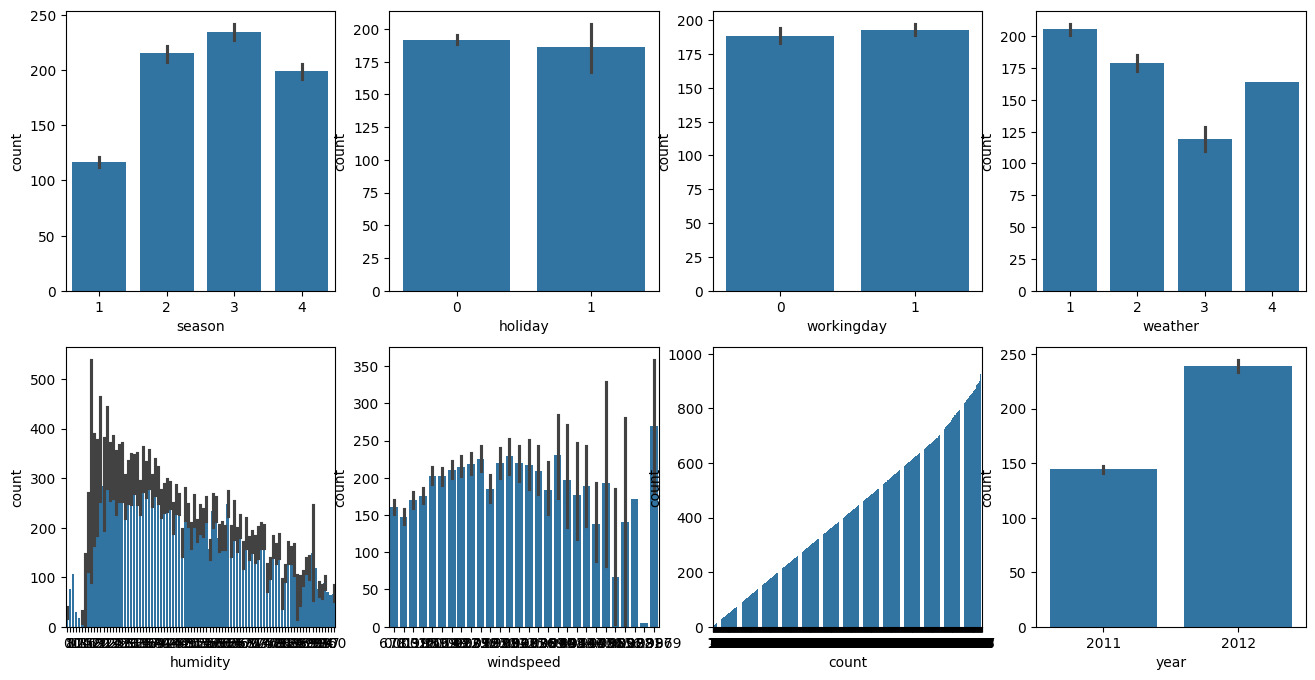

In [ ]:
# 타겟 변수에 대한 각 컬럼과의 관계 시각화
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['season', 'holiday', 'workingday', 'weather', 'humidity', 'windspeed', 'count', 'year']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    sns.barplot(x=feature, y ='count', data=train_data, ax=axs[row][col])

# 대여 횟수가 2012년도가 전년도에 비해 많이 증가하였음.
# 평일, 주말 상관없이 고르게 분포
# 봄에 유독 덜 빌리고 가을에 제일 많이 대여한 것을 파악.
# 날씨가 안좋을때 대여빈도가 작음

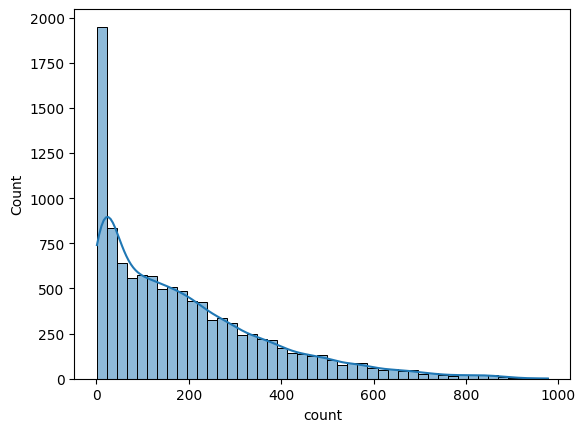

In [ ]:
# 타겟 변수가 정규분포를 이루고 있지 않음. => 로그화 시켜주기.
sns.histplot(train_data['count'], kde=True)
plt.show()

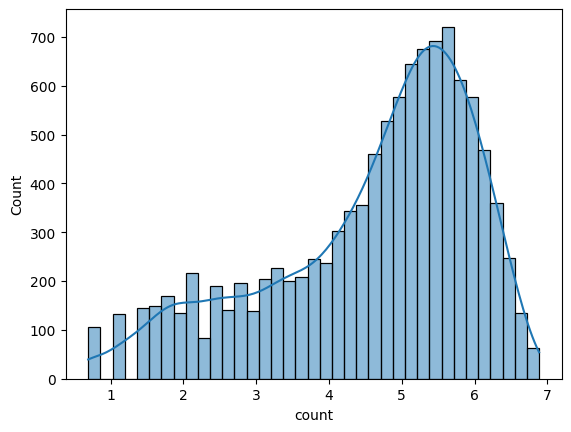

In [ ]:
# 로그화를 통해 정규분포를 만들려고 했으나 만족 못함....
log_count = np.log1p(train_data['count'])
sns.histplot(log_count, kde=True)
plt.show()

In [ ]:
# 컬럼들간의 크기를 어느정도 통일해주기 위해 정규화 과정이 필요해보임.
# 계절, 날씨 컬럼은 더미화 해주는게 좋아보임.(원-핫 인코딩)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_data.drop('count', axis=1))
scaled_features = scaler.transform(train_data.drop('count', axis=1))

In [ ]:
train_data.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,32,2011,1,1,2


In [ ]:
dt = pd.get_dummies(train_data, columns = ['season', 'weather'], dtype=float)

In [ ]:
dt.head()

,holiday,workingday,temp,atemp,humidity,windspeed,count,year,month,day,hour,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0,0,9.84,14.395,81,0.0,16,2011,1,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,0,9.02,13.635,80,0.0,40,2011,1,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,0,9.02,13.635,80,0.0,32,2011,1,1,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,0,9.84,14.395,75,0.0,13,2011,1,1,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,0,9.84,14.395,75,0.0,1,2011,1,1,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


1. 선형회귀

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
%matplotlib inline

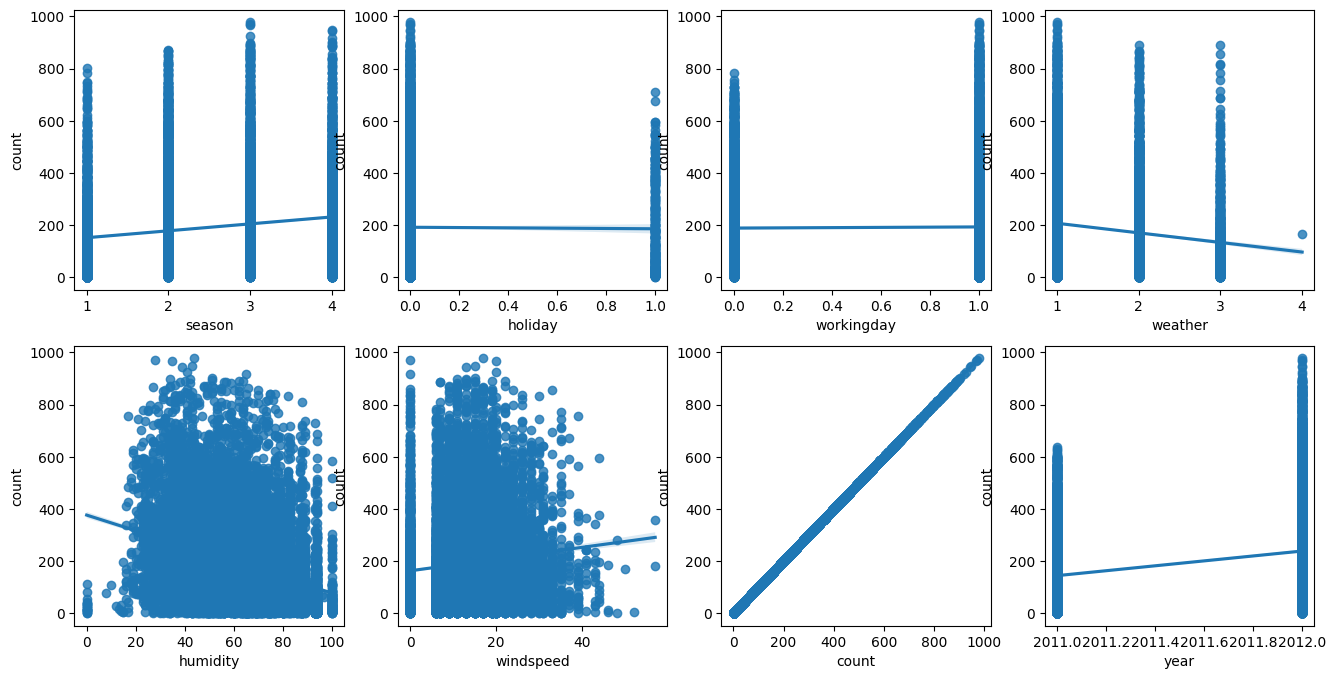

In [ ]:
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['season', 'holiday', 'workingday', 'weather', 'humidity', 'windspeed', 'count', 'year']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    sns.regplot(x=feature, y ='count', data=train_data, ax=axs[row][col])

In [ ]:
X_data = dt.drop(['count'], axis=1, inplace=False)
y_target = train_data['count']

y_target_log = np.log1p(y_target)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_target_log , test_size=0.3, random_state=156)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE: {1:.3f}'.format(mse, rmse))
print('Variance socre: {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 0.973, RMSE: 0.986
Variance socre: 0.522


In [ ]:
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, X_data, y_target_log,
                                 scoring = 'neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds 의 개별 Negative MSE scores:', np.round(neg_mse_scores,2))
print(' 5 folds 의 개별 RMSE scores:', np.round(rmse_scores,2))
print(' 5 folds 의 평균 RMSE : {0:.3f}'.format(avg_rmse))

 5 folds 의 개별 Negative MSE scores: [-1.1  -0.89 -1.18 -1.06 -1.  ]
 5 folds 의 개별 RMSE scores: [1.05 0.94 1.09 1.03 1.  ]
 5 folds 의 평균 RMSE : 1.022


2. 릿지 회귀

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target_log, scoring="neg_mean_squared_error", cv=5)
rmse_scores =np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

alphas = [0, 0.1, 1, 10, 100]

for alpha in alphas:
    ridge = Ridge(alpha =alpha)

    neg_mse_scores = cross_val_score(ridge, X_data, y_target_log, scoring="neg_mean_squared_error", cv=5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha {0} 일 때 5 folds 의 평균 RMSE:{1:.3f}'.format(alpha, avg_rmse))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=4.58602e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


alpha 0 일 때 5 folds 의 평균 RMSE:217754665475.646
alpha 0.1 일 때 5 folds 의 평균 RMSE:1.022
alpha 1 일 때 5 folds 의 평균 RMSE:1.022
alpha 10 일 때 5 folds 의 평균 RMSE:1.022
alpha 100 일 때 5 folds 의 평균 RMSE:1.021


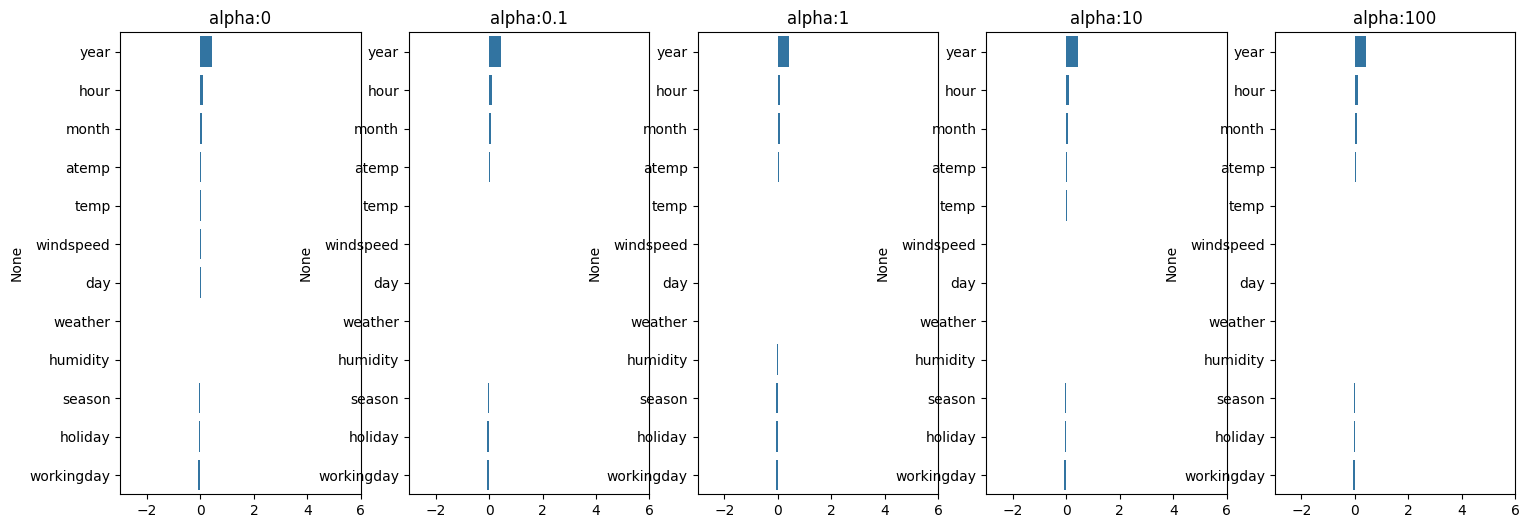

In [ ]:
fig, axs = plt.subplots(figsize=(18,6), ncols=5, nrows=1)

coeff_df = pd.DataFrame()

for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(X, y_log)

    coeff = pd.Series(data=ridge.coef_, index= X.columns)
    colname = 'alpha:' + str(alpha)
    coeff_df[colname] = coeff

    coeff = coeff.sort_values(ascending= False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x = coeff.values, y = coeff.index, ax=axs[pos])

plt.show()

In [ ]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+ str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending= False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
year,0.428611,0.428595,0.428451,0.427015,0.413186
hour,0.098086,0.098086,0.098086,0.098081,0.098031
month,0.075788,0.075786,0.075763,0.075532,0.073402
atemp,0.035539,0.035539,0.035539,0.035536,0.035486
temp,0.007250,0.007250,0.007251,0.007258,0.007359
windspeed,0.004667,0.004666,0.004666,0.004661,0.004616
day,0.003028,0.003028,0.003028,0.003029,0.003035
weather,-0.005005,-0.005005,-0.005000,-0.004960,-0.004574
humidity,-0.014562,-0.014562,-0.014562,-0.014566,-0.014602
season,-0.049919,-0.049911,-0.049839,-0.049125,-0.042558


In [ ]:
from sklearn.linear_model import Lasso, ElasticNet

def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_log_n=None, verbose=True, return_coeff=True):
  coeff_df = pd.DataFrame()
  if verbose: print('######', model_name, '######')
  for param in params:
    if model_name == 'Ridge': model = Ridge(alpha=param)
    elif model_name == 'Lasso': model = Lasso(alpha=param)
    elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
    neg_mse_scores = cross_val_score(model, X_data_n, y_target_log_n, scoring="neg_mean_squared_error", cv=5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha {0} 일 때 5 folds 의 평균 RMSE:{1:.3f}'.format(param, avg_rmse))

    model.fit(X_data_n, y_target_log_n)
    if return_coeff:
      coeff = pd.Series(data=model.coef_, index= X_data_n.columns)
      colname = 'alpha:' + str(param)
      coeff_df[colname] = coeff
  return coeff_df

In [ ]:
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_log_n=y_target_log)

###### Lasso ######
alpha 0.07 일 때 5 folds 의 평균 RMSE:1.079
alpha 0.1 일 때 5 folds 의 평균 RMSE:1.096
alpha 0.5 일 때 5 folds 의 평균 RMSE:1.106
alpha 1 일 때 5 folds 의 평균 RMSE:1.114
alpha 3 일 때 5 folds 의 평균 RMSE:1.227


In [ ]:
sort_column = 'alpha:'+ str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_column, ascending= False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
year,0.145409,0.024015,0.000000,0.000000,0.000000
hour,0.096264,0.095481,0.088532,0.079460,0.042669
month,0.053585,0.050741,0.015254,0.000000,0.000000
atemp,0.036576,0.036934,0.042200,0.038005,0.014494
temp,0.006792,0.006766,0.000000,0.000000,0.000000
windspeed,0.002746,0.001956,0.000000,0.000000,0.000000
day,0.000790,0.000000,0.000000,0.000000,0.000000
season_3,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
weather_3,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
weather_2,0.000000,0.000000,0.000000,0.000000,0.000000


3. 엘라스틱 회귀

In [ ]:
elastic_aplhas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_aplhas, X_data_n=X_data, y_target_log_n=y_target_log)

###### ElasticNet ######
alpha 0.07 일 때 5 folds 의 평균 RMSE:1.056
alpha 0.1 일 때 5 folds 의 평균 RMSE:1.081
alpha 0.5 일 때 5 folds 의 평균 RMSE:1.107
alpha 1 일 때 5 folds 의 평균 RMSE:1.108
alpha 3 일 때 5 folds 의 평균 RMSE:1.168


In [ ]:
sort_column = 'alpha:'+ str(elastic_aplhas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending= False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
year,0.212298,0.129627,0.000000,0.000000,0.000000
hour,0.096726,0.096165,0.090890,0.084433,0.058098
month,0.055448,0.053422,0.028100,0.000000,0.000000
atemp,0.035890,0.036161,0.041627,0.041417,0.024883
temp,0.007364,0.007318,0.000954,0.000000,0.000000
windspeed,0.003232,0.002688,0.000000,0.000000,0.000000
day,0.001454,0.000790,0.000000,0.000000,0.000000
season_3,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
weather_3,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
weather_2,0.000000,0.000000,0.000000,0.000000,0.000000


4. XGBR, RFR, GBMR, LGBMR

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
rf = RandomForestRegressor(n_estimators=1000, random_state=0)
neg_mse_scores = cross_val_score(rf, X_data, y_target_log, scoring="neg_mean_squared_error", cv=5)
rmse_scores =np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 교차 검증의 개별 Negative MSE scores:', np.round(neg_mse_scores,2))
print(' 5 교차 검증의 개별 RMSE scores:', np.round(rmse_scores,2))
print(' 5 교차 검증의 평균 RMSE : {0:.3f}'.format(avg_rmse))

 5 교차 검증의 개별 Negative MSE scores: [-0.5  -0.13 -0.23 -0.15 -0.16]
 5 교차 검증의 개별 RMSE scores: [0.7  0.37 0.48 0.38 0.4 ]
 5 교차 검증의 평균 RMSE : 0.468


In [ ]:
def get_model_cv_prediction(model, X_data, y_target_log):
  neg_mse_scores = cross_val_score(model, X_data, y_target_log, scoring="neg_mean_squared_error", cv=5)
  rmse_scores =np.sqrt(-1*neg_mse_scores)
  avg_rmse = np.mean(rmse_scores)
  print('#####', model.__class__.__name__, '#####')
  print(' 5 교차 검증의 평균 RMSE : {0:.3f}'.format(avg_rmse))

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=0)
gb_reg = GradientBoostingClassifier(n_estimators=1000, random_state=0)
xgb_reg = XGBRegressor(n_estimators=1000)
lgb_reg = LGBMRegressor(n_estimators=1000)

models = [rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:
  get_model_cv_prediction(model, X_data, y_target_log)

##### RandomForestRegressor #####
 5 교차 검증의 평균 RMSE : 0.468


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py", line 427, in fit
    y = self._validate_y(y, sample_weight)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py", line 1213, in _validate_y
    check_classification_targets(y)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/multiclass.p

책 과정과 똑같이 수행

In [ ]:
bike_df = pd.read_csv('/content/train.csv')
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [ ]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

In [ ]:
bike_df['year'] = bike_df.datetime.apply(lambda x : x.year)
bike_df['month'] = bike_df.datetime.apply(lambda x : x.month)
bike_df['day'] = bike_df.datetime.apply(lambda x : x.day)
bike_df['hour'] = bike_df.datetime.apply(lambda x : x.hour)
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2


In [ ]:
drop_columns = ['datetime', 'casual', 'registered']
bike_df.drop(drop_columns, axis=1, inplace=True)

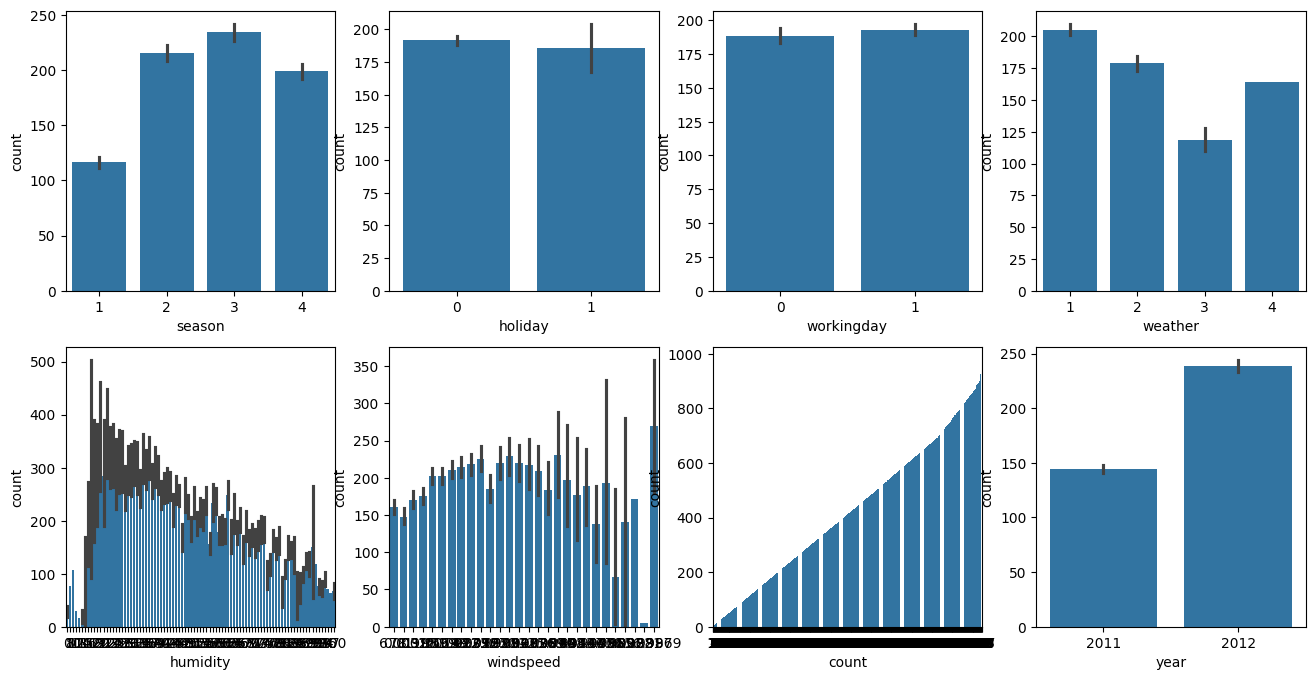

In [ ]:
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['season', 'holiday', 'workingday', 'weather', 'humidity', 'windspeed', 'count', 'year']

for i, feature in enumerate(lm_features):
  row = int(i/4)
  col = i%4
  sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row][col])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmsle(y, pred):
  log_y = np.log1p(y)
  log_pred = np.log1p(pred)
  squared_error = (log_y - log_pred) ** 2
  rmsle = np.sqrt(np.mean(squared_error))
  return rmsle

def rmse(y, pred):
  return np.sqrt(mean_squared_error(y, pred))

def evaluate_regr(y, pred):
  rmsle_val = rmsle(y, pred)
  rmse_val = rmse(y, pred)
  mae_val = mean_absolute_error(y, pred)
  print('RMSLE: {0:.3f}, RMSE: {1:.3f}, MAE: {2:.3f}'.format(rmsle_val, rmse_val, mae_val))

In [ ]:
def rmsle(y, pred):
  msle = mean_squared_error(y, pred)
  rmsle =np.sqrt(mse)
  return rmsle

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso

y_target = bike_df['count']
X_features = bike_df.drop(['count'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)

evaluate_regr(y_test, pred)

RMSLE: 1.165, RMSE: 140.900, MAE: 105.924


<ipython-input-120-963910698c61>:5: RuntimeWarning: invalid value encountered in log1p
  log_pred = np.log1p(pred)


In [ ]:
def get_top_error_data(y_test, pred, n_tops=5):
  result_df = pd.DataFrame(y_test.values, columns=['real_count'])
  result_df['predicted_count'] = np.round(pred)
  result_df['diff'] = np.abs(result_df['real_count'] - result_df['predicted_count'])

  print(result_df.sort_values('diff', ascending=False)[:n_tops])

get_top_error_data(y_test, pred, n_tops=5)

      real_count  predicted_count   diff
1618         890            322.0  568.0
3151         798            241.0  557.0
966          884            327.0  557.0
412          745            194.0  551.0
2817         856            310.0  546.0


In [ ]:
y_log_transform = np.log1p(y_target)
y_log_transform.head()

,count
0,2.833213
1,3.713572
2,3.496508
3,2.639057
4,0.693147


In [ ]:
y_target_log =np.log1p(y_target)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target_log, test_size=0.3, random_state=0)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)

y_test_exp = np.expm1(y_test)
pred_exp = np.expm1(pred)

evaluate_regr(y_test_exp, pred_exp)

RMSLE: 1.017, RMSE: 162.594, MAE: 109.286


<Axes: ylabel='None'>

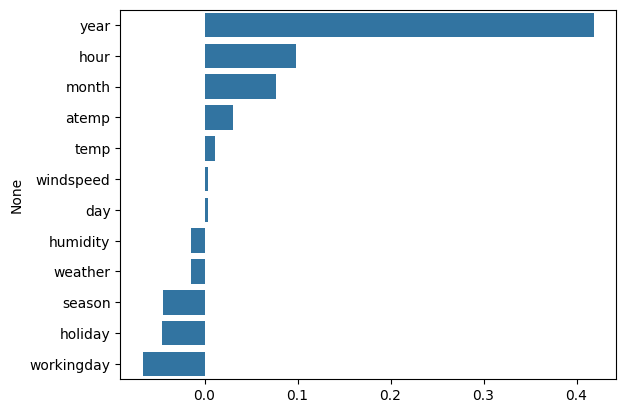

In [ ]:
coef = pd.Series(lr_reg.coef_, index=X_features.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

In [ ]:
X_features_ohe = pd.get_dummies(bike_df, columns=['year','month','day','hour','holiday',
                                                  'workingday', 'season', 'weather'])

X_train, X_test, y_train, y_test = train_test_split(X_features_ohe, y_target_log, test_size=0.3, random_state=0)

def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False):
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  if is_expm1:
    y_test = np.expm1(y_test)
    pred = np.expm1(pred)
  print('###', model.__class__.__name__, '###')
  evaluate_regr(y_test, pred)

lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)

for model in [lr_reg, ridge_reg, lasso_reg]:
  get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=True)


### LinearRegression ###
RMSLE: 0.478, RMSE: 123.726, MAE: 50.662
### Ridge ###
RMSLE: 0.479, RMSE: 136.145, MAE: 53.109
### Lasso ###
RMSLE: 0.532, RMSE: 248.009, MAE: 78.755


<Axes: ylabel='None'>

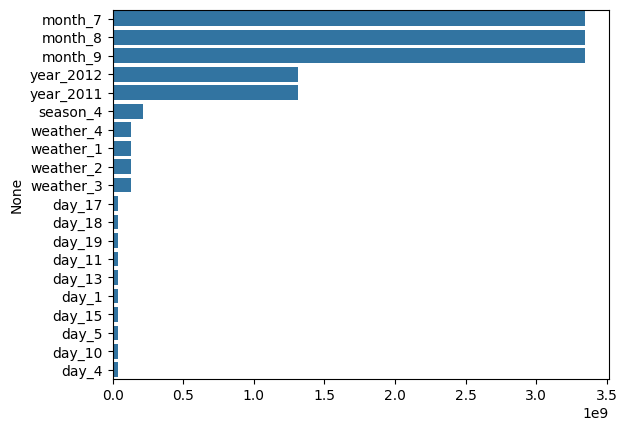

In [ ]:
coef = pd.Series(lr_reg.coef_, index=X_features_ohe.columns)
coef_sort = coef.sort_values(ascending=False)[:20]
sns.barplot(x=coef_sort.values, y=coef_sort.index)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf_reg = RandomForestRegressor(n_estimators=500)
gb_reg = GradientBoostingRegressor(n_estimators=5000)
xgb_reg = XGBRegressor(n_estimators=500)
lgb_reg = LGBMRegressor(n_estimators=500)

for model in [rf_reg, gb_reg, xgb_reg, lgb_reg]:
  get_model_predict(model, X_train.values, X_test.values, y_train.values, y_test.values, is_expm1=True)

### RandomForestRegressor ###
RMSLE: 0.000, RMSE: 0.325, MAE: 0.049
### GradientBoostingRegressor ###
RMSLE: 0.001, RMSE: 0.473, MAE: 0.160
### XGBRegressor ###
RMSLE: 0.005, RMSE: 2.214, MAE: 0.922
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 603
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 73
[LightGBM] [Info] Start training from score 4.582043
### LGBMRegressor ###
RMSLE: 0.005, RMSE: 1.839, MAE: 0.737
